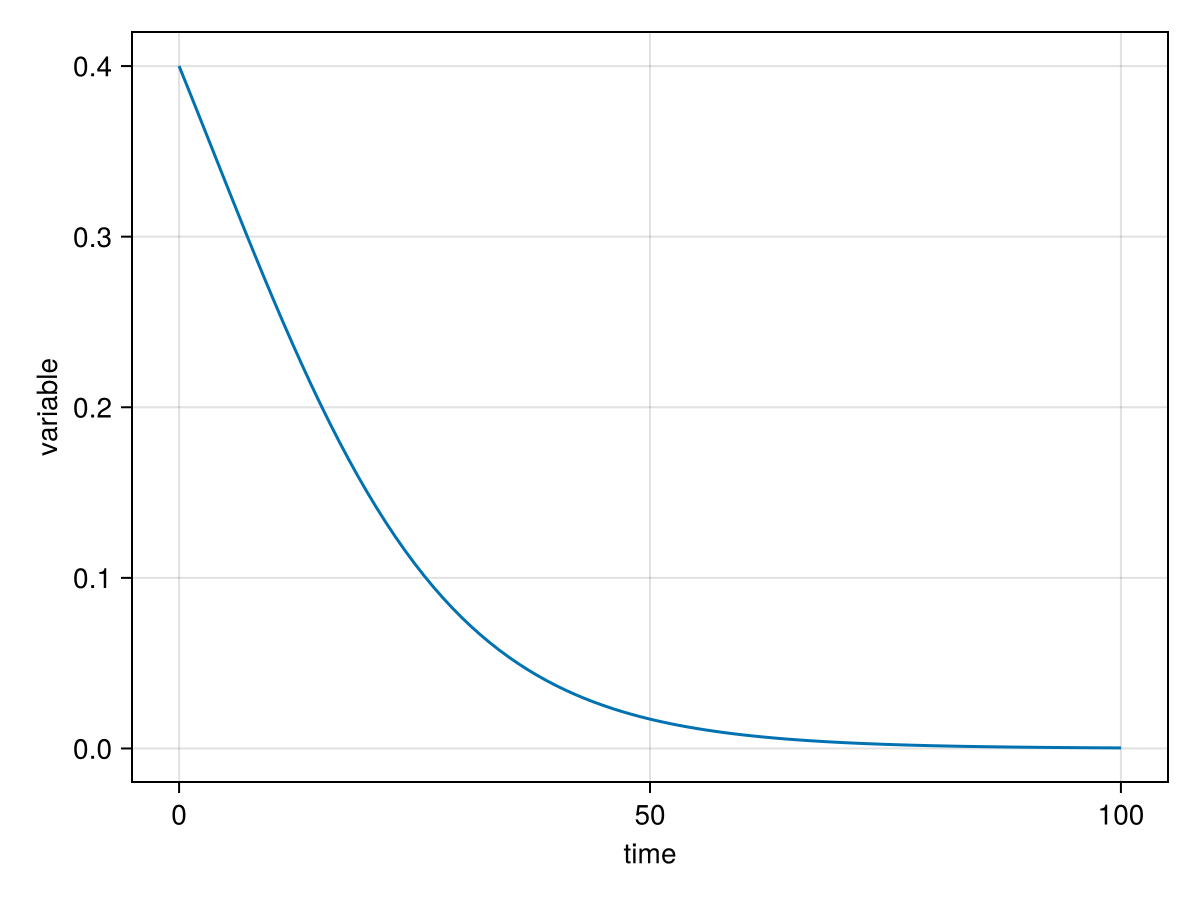

In [1]:
using DynamicalSystemsBase
using CairoMakie

p = Dict(
    :T => 289.65,
    :T_opt => 265.65,
    :λ_opt => 0.05,
    :k => 32.5,
    :I => 0.3
)

function plant(u,p,t)
    b = u[1]
    p = NamedTuple(p)
    g = 1 - b - p.I
    λ_b = loss_b(p.T, p.T_opt, p.k, p.λ_opt)
    β_b = growth_b(p.T, p.T_opt, p.k)
    db = b * (g*(β_b - λ_b))
    return SVector(db)
end
function growth_b(T, T_opt, k) # Growth function for plants
    if k > abs(T - T_opt) #If temperature is outside deviation, then growth=0
        return(1-(k^-2)*(T-T_opt)^2) #Ask Dylaan how this works
    else
        return(0)
    end
end
function loss_b(T, T_opt, k, λ_bopt) # loss function for plants
    if k > abs(T - T_opt) #If temperature is outside deviation, then loss=1
        return(λ_bopt+(1-λ_bopt)*(k^-2)*(T-T_opt)^2) #draai de groeifunctie om en+
    else
        return(1)
    end
end

u0 = [0.4]
t0 = 0.0
ds = CoupledODEs(plant, u0, p)

t_total = 100.0
dt = 1.0
X, t = trajectory(ds, t_total; Δt=dt)


fig = Figure()
ax = Axis(fig[1, 1]; xlabel = "time", ylabel = "variable")
for var in columns(X)
    lines!(ax, t, var)
end
fig
